# Heart Disease Prediction Project
This notebook includes:
- Data loading
- Visualization (EDA)
- Outlier removal
- Feature scaling (Standardization)
- Logistic Regression (main)
- Linear & Polynomial Regression (comparison)
- Regression metrics (MAE, MSE, RMSE, R²)
- Evaluation (Accuracy, Confusion Matrix)
- Best overall performer(Random Forest)
- Simple baseline model (KNN)
- Strong classification boundary (SVM)
- Feature selection (Lasso)
- Reduce overfitting (Ridge)



In [1]:
# =====================================
# 1. IMPORT LIBRARIES
# =====================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report,mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import Lasso, Ridge


In [2]:
# =====================================
# 2. LOAD DATASET
# =====================================
df = pd.read_csv(r"C:\Users\suhas\Downloads\heart.csv")
df.head()


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [3]:
# =====================================
# 3. BASIC INFO
# =====================================
print(df.info())
print(df.describe())
print(df.isnull().sum())


<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB
None
               age          sex           cp     trestbps        chol  \
count  1025.000000  1025.000000  1025.000000  1025.000000  1025.00000   
mean     54.434146     0.695610     0.942439   131.611707   246.00000   
std

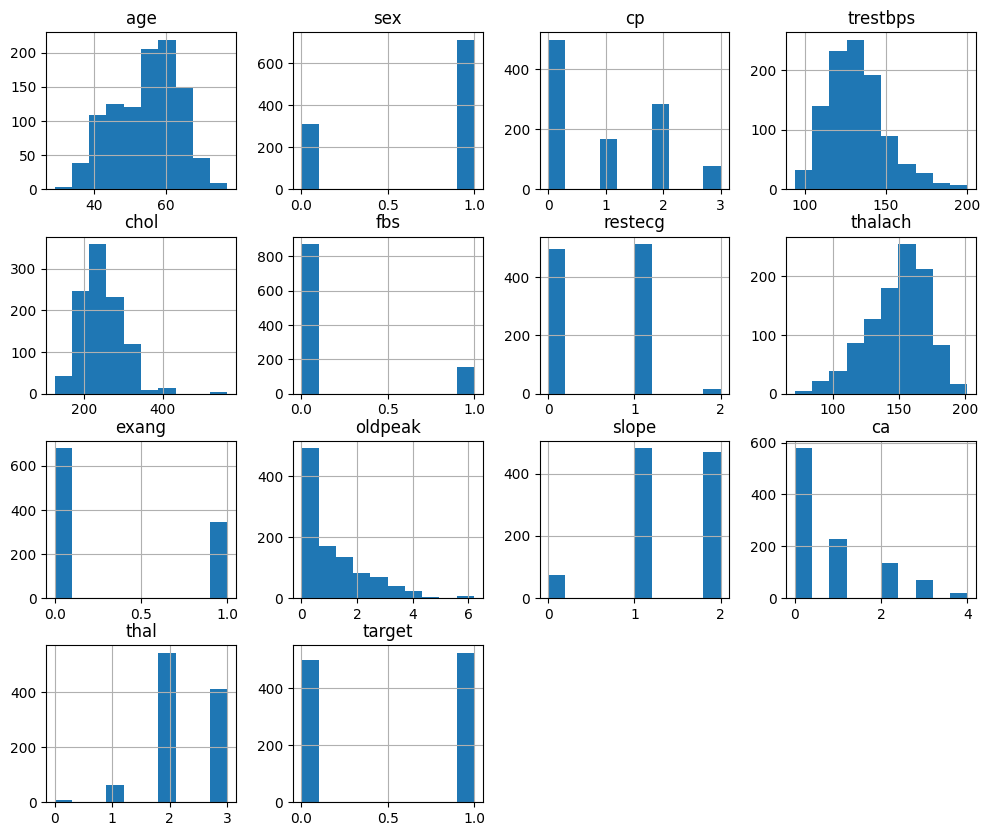

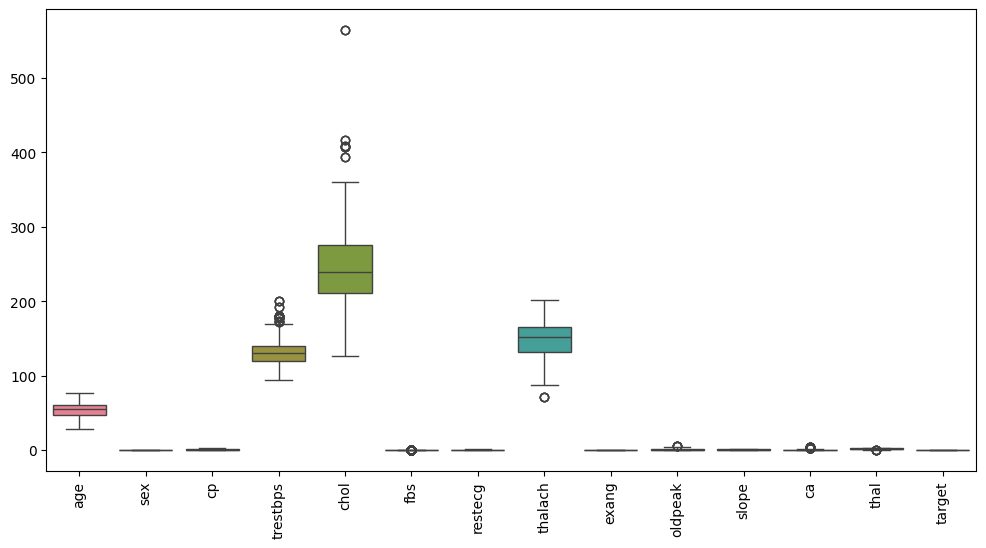

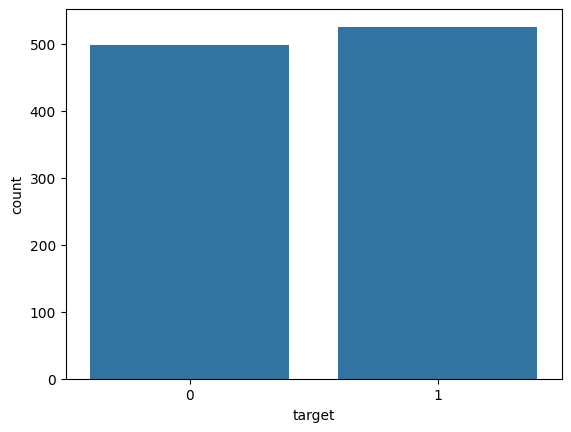

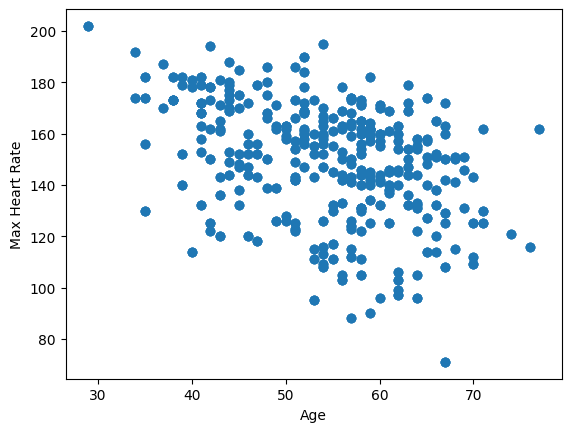

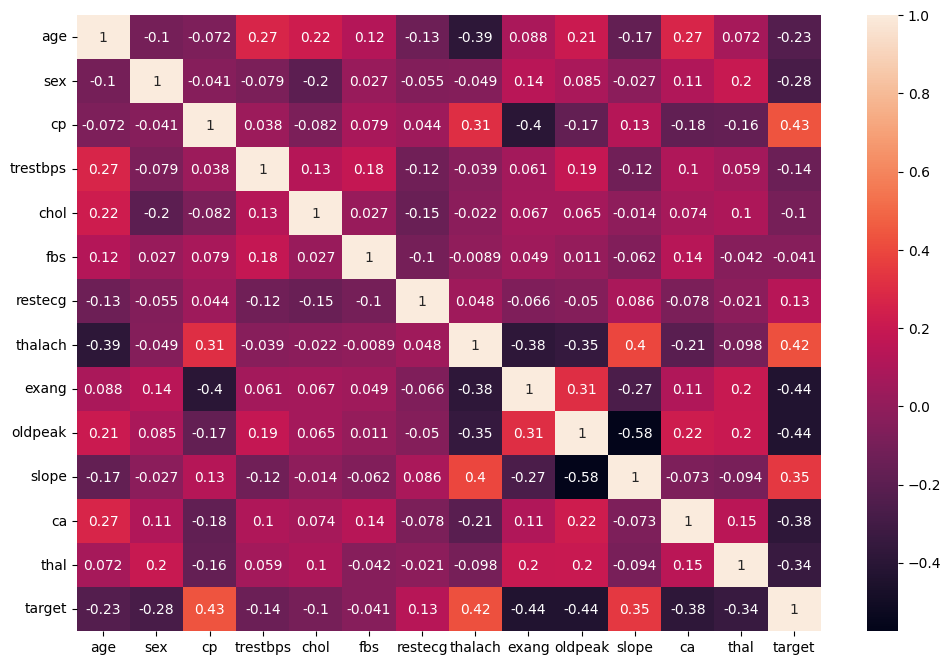

In [4]:
# =====================================
# 4. VISUALIZATION
# =====================================

# Histogram
df.hist(figsize=(12,10))
plt.show()

# Boxplot
plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.show()

# Count plot
sns.countplot(x='target', data=df)
plt.show()

# Scatter plot
plt.scatter(df['age'], df['thalach'])
plt.xlabel('Age')
plt.ylabel('Max Heart Rate')
plt.show()

# Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True)
plt.show()


In [5]:
# =====================================
# 5. OUTLIER REMOVAL (IQR)
# =====================================
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1

df = df[~((df < (Q1 - 1.5 * IQR)) |
          (df > (Q3 + 1.5 * IQR))).any(axis=1)]

df.shape


(769, 14)

In [6]:
# =====================================
# 6. SPLIT DATA
# =====================================
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [7]:
# =====================================
# 7. FEATURE SCALING
# =====================================
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [8]:
# =====================================
# 8. LOGISTIC REGRESSION
# =====================================
log_model = LogisticRegression()
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

print('Accuracy:', accuracy_score(y_test, y_pred_log))
print(confusion_matrix(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))


Accuracy: 0.8571428571428571
[[49 15]
 [ 7 83]]
              precision    recall  f1-score   support

           0       0.88      0.77      0.82        64
           1       0.85      0.92      0.88        90

    accuracy                           0.86       154
   macro avg       0.86      0.84      0.85       154
weighted avg       0.86      0.86      0.86       154



In [9]:
# =====================================
# 9. LINEAR REGRESSION
# =====================================
lin_model = LinearRegression()
lin_model.fit(X_train, y_train)

y_pred_lin = lin_model.predict(X_test)
y_pred_lin_binary = [1 if i > 0.5 else 0 for i in y_pred_lin]

print('Accuracy:', accuracy_score(y_test, y_pred_lin_binary))


Accuracy: 0.8506493506493507


In [10]:
# =====================================
# 10. REGRESSION METRICS
# =====================================
print('MAE:', mean_absolute_error(y_test, y_pred_lin))
print('MSE:', mean_squared_error(y_test, y_pred_lin))
print('RMSE:', np.sqrt(mean_squared_error(y_test, y_pred_lin)))
print('R2:', r2_score(y_test, y_pred_lin))


MAE: 0.2883363330190877
MSE: 0.12765092764513128
RMSE: 0.3572826998962184
R2: 0.47441503471667823


In [11]:
# =====================================
# 11. POLYNOMIAL REGRESSION
# =====================================
poly = PolynomialFeatures(degree=2)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)

y_pred_poly = poly_model.predict(X_test_poly)
y_pred_poly_binary = [1 if i > 0.5 else 0 for i in y_pred_poly]

print('Accuracy:', accuracy_score(y_test, y_pred_poly_binary))


Accuracy: 0.8831168831168831


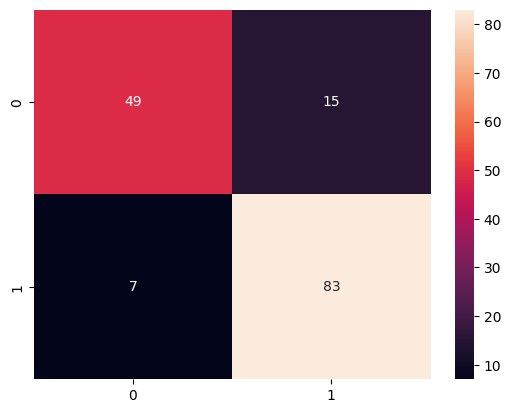

In [12]:
# =====================================
# 12. CONFUSION MATRIX
# =====================================
sns.heatmap(confusion_matrix(y_test, y_pred_log), annot=True, fmt='d')
plt.show()


In [13]:
# =====================================
# 13. RANDOM FOREST
# =====================================

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 1.0
[[64  0]
 [ 0 90]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        64
           1       1.00      1.00      1.00        90

    accuracy                           1.00       154
   macro avg       1.00      1.00      1.00       154
weighted avg       1.00      1.00      1.00       154



In [14]:
# =====================================
# 14. KNN
# =====================================

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

y_pred_knn = knn_model.predict(X_test)

print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print(confusion_matrix(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))

KNN Accuracy: 0.8701298701298701
[[54 10]
 [10 80]]
              precision    recall  f1-score   support

           0       0.84      0.84      0.84        64
           1       0.89      0.89      0.89        90

    accuracy                           0.87       154
   macro avg       0.87      0.87      0.87       154
weighted avg       0.87      0.87      0.87       154



In [15]:
# =====================================
# 15. SVM
# =====================================

svm_model = SVC(kernel='rbf')   # you can also try 'linear'
svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_test)

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print(confusion_matrix(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

SVM Accuracy: 0.935064935064935
[[57  7]
 [ 3 87]]
              precision    recall  f1-score   support

           0       0.95      0.89      0.92        64
           1       0.93      0.97      0.95        90

    accuracy                           0.94       154
   macro avg       0.94      0.93      0.93       154
weighted avg       0.94      0.94      0.93       154



In [16]:
# =====================================
# 16. LASSO
# =====================================

lasso_model = Lasso(alpha=0.01)
lasso_model.fit(X_train, y_train)

y_pred_lasso = lasso_model.predict(X_test)
y_pred_lasso_binary = [1 if i > 0.5 else 0 for i in y_pred_lasso]

print("Lasso Accuracy:", accuracy_score(y_test, y_pred_lasso_binary))

# Feature importance (important for your viva!)
lasso_features = pd.Series(lasso_model.coef_, index=X.columns)
print("Lasso Selected Features:")
print(lasso_features)

Lasso Accuracy: 0.8376623376623377
Lasso Selected Features:
age         0.000000
sex        -0.079797
cp          0.087225
trestbps   -0.018438
chol       -0.003228
fbs         0.000000
restecg     0.009724
thalach     0.048888
exang      -0.039770
oldpeak    -0.060477
slope       0.063230
ca         -0.123622
thal       -0.111539
dtype: float64


In [17]:
# =====================================
# 17. RIDGE
# =====================================

ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)

y_pred_ridge = ridge_model.predict(X_test)
y_pred_ridge_binary = [1 if i > 0.5 else 0 for i in y_pred_ridge]

print("Ridge Accuracy:", accuracy_score(y_test, y_pred_ridge_binary))

Ridge Accuracy: 0.8506493506493507


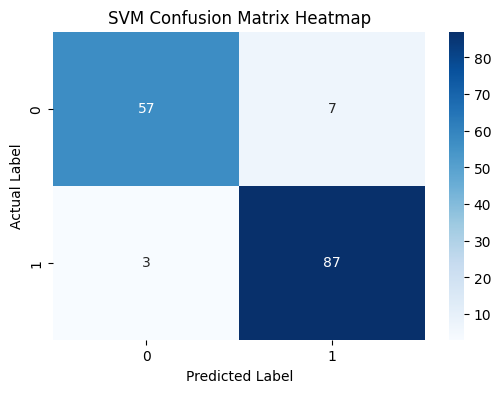

In [18]:
cm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("SVM Confusion Matrix Heatmap")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()